# Section A: Concept Application

## 1. What is the difference between a `.py` file and a `.ipynb` file?

A **`.py`** file is a standard Python script that contains only Python code. It is mainly used for developing Python applications and is executed as a complete program.

A **`.ipynb`** file is a Jupyter Notebook file. It contains Python code, text, images, tables, graphs, and outputs in a single document. Code is executed one cell at a time, making it ideal for data analysis and machine learning.

| `.py` File | `.ipynb` File |
|------------|---------------|
| Contains only Python code | Contains code, text, images, and output |
| Runs as a complete script | Runs one cell at a time |
| Used for software development | Used for data analysis and experimentation |

---

## 2. What is the difference between a numerical feature and a categorical feature?

A **numerical feature** contains measurable values that can be used for mathematical calculations. Examples include **age**, **cholesterol**, and **maximum heart rate (thalach)**.

A **categorical feature** contains labels or categories instead of measurable values. Examples include **sex**, **chest pain type (cp)**, and **resting ECG (restecg)**.

| Numerical Feature | Categorical Feature |
|-------------------|---------------------|
| Contains numeric values | Contains categories or labels |
| Mathematical operations can be performed | Represents different groups |
| Example: Age, Cholesterol | Example: Sex, CP, RestECG |

---

## 3. Why does the data type of your target variable matter before framing a prediction problem?

The data type of the target variable helps determine the type of machine learning problem.

If the target column contains integer values such as **0** and **1**, it usually represents categories, making it a **classification** problem.

If the target column contains continuous numerical values, it becomes a **regression** problem.

Checking the data type before building a model also helps avoid errors and ensures the correct machine learning algorithm is selected.

---

## 4. What does a correlation value of **0.23** tell you about two variables?

Correlation measures the strength and direction of the relationship between two variables.

A correlation value of **0.23** indicates a **weak positive correlation** between age and heart disease.

This means that as age increases, the likelihood of heart disease increases slightly, but the relationship is not very strong.

The correlation coefficient ranges from **-1 to +1**.

- **+1** → Perfect positive correlation
- **0** → No correlation
- **-1** → Perfect negative correlation

---

## 5. What is the fundamental difference between a rule-based system and a data-driven approach?

A **rule-based system** works using predefined rules created by experts. For example, if **cholesterol > 240**, the patient is classified as high risk. These rules remain fixed unless manually updated.

A **data-driven approach** uses historical data and machine learning algorithms to learn patterns automatically. Instead of relying on one rule, it considers multiple features such as age, cholesterol, blood pressure, heart rate, and chest pain to make predictions.

| Rule-Based System | Data-Driven Approach |
|-------------------|----------------------|
| Uses fixed rules | Learns patterns from data |
| Rules are manually created | Model is trained using data |
| Less flexible | Improves with more data |
| Uses expert-defined thresholds | Uses statistical and machine learning techniques |

A data-driven approach generally provides more accurate predictions because it considers the combined effect of multiple clinical features instead of relying on a single condition.

# SECTION - B
# Practical Task 1


Load the UCI Heart Disease dataset using Pandas and perform type-casting for categorical variables such as **sex**, **cp**, and **restecg**.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:

df = pd.read_csv("heart_cleveland_upload.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


# Practical Task 2

In [4]:

def detect_outliers(column_name):
    
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column_name] < lower_limit) |
        (df[column_name] > upper_limit)
    ]

    print(f"{column_name}")
    print(f"Number of Outliers: {len(outliers)}")
    print("-" * 40)

# Detect outliers
detect_outliers("chol")
detect_outliers("thalach")

chol
Number of Outliers: 5
----------------------------------------
thalach
Number of Outliers: 1
----------------------------------------


# Practical Task 3

In [5]:
# Calculate the correlation matrix

correlation = df.corr(numeric_only=True)

# Display the correlation matrix
correlation

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
age,1.000000,-0.092399,0.110471,0.290476,0.202644,0.132062,0.149917,-0.394563,0.096489,0.197123,0.159405,0.362210,0.120795,0.227075
sex,-0.092399,1.000000,0.008908,-0.066340,-0.198089,0.038850,0.033897,-0.060496,0.143581,0.106567,0.033345,0.091925,0.370556,0.278467
cp,0.110471,0.008908,1.000000,-0.036980,0.072088,-0.057663,0.063905,-0.339308,0.377525,0.203244,0.151079,0.235644,0.266275,0.408945
trestbps,0.290476,-0.066340,-0.036980,1.000000,0.131536,0.180860,0.149242,-0.049108,0.066691,0.191243,0.121172,0.097954,0.130612,0.153490
chol,0.202644,-0.198089,0.072088,0.131536,1.000000,0.012708,0.165046,-0.000075,0.059339,0.038596,-0.009215,0.115945,0.023441,0.080285
fbs,0.132062,0.038850,-0.057663,0.180860,0.012708,1.000000,0.068831,-0.007842,-0.000893,0.008311,0.047819,0.152086,0.051038,0.003167
restecg,0.149917,0.033897,0.063905,0.149242,0.165046,0.068831,1.000000,-0.072290,0.081874,0.113726,0.135141,0.129021,0.013612,0.166343
thalach,-0.394563,-0.060496,-0.339308,-0.049108,-0.000075,-0.007842,-0.072290,1.000000,-0.384368,-0.347640,-0.389307,-0.268727,-0.258386,-0.423817
exang,0.096489,0.143581,0.377525,0.066691,0.059339,-0.000893,0.081874,-0.384368,1.000000,0.289310,0.250572,0.148232,0.323268,0.421355
oldpeak,0.197123,0.106567,0.203244,0.191243,0.038596,0.008311,0.113726,-0.347640,0.289310,1.000000,0.579037,0.294452,0.336809,0.424052


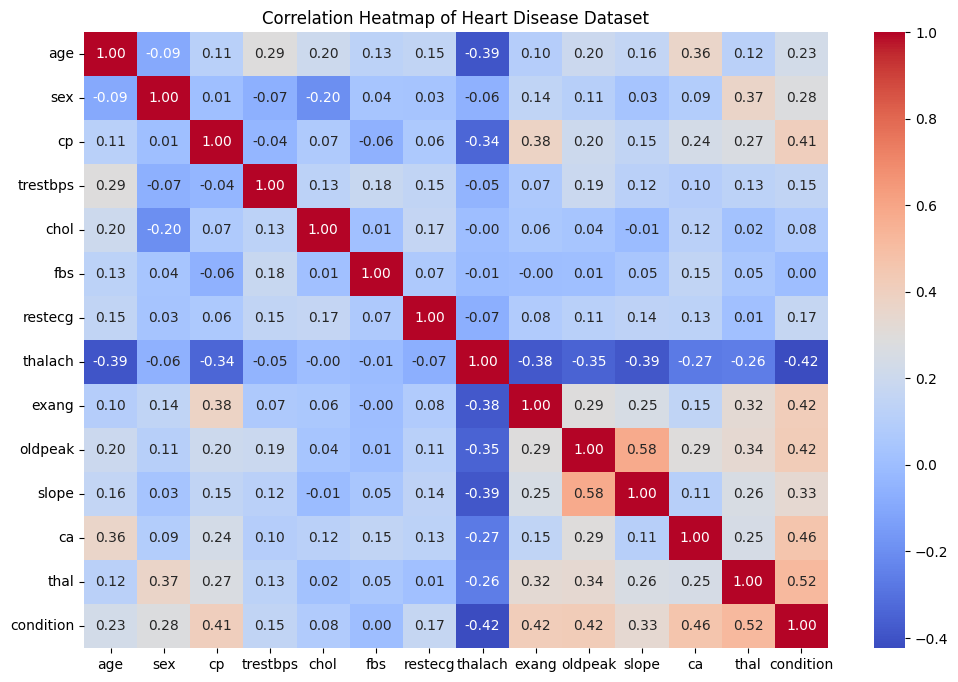

In [ ]:
# Draw Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(correlation,
            annot=True,
            cmap="coolwarm"
            )

plt.title("Correlation Heatmap of Heart Disease Dataset")

plt.show()

In [9]:
# Correlation with target column

target_corr = correlation["condition"].sort_values(ascending=False)

print("Correlation with Target Variable")
print(target_corr)

Correlation with Target Variable
condition    1.000000
thal         0.520516
ca           0.463189
oldpeak      0.424052
exang        0.421355
cp           0.408945
slope        0.333049
sex          0.278467
age          0.227075
restecg      0.166343
trestbps     0.153490
chol         0.080285
fbs          0.003167
thalach     -0.423817
Name: condition, dtype: float64


# Practical Task 4



In [11]:
from sklearn.preprocessing import StandardScaler

In [12]:
# Select numerical columns

numerical_columns = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

# Normalize the numerical features

scaler = StandardScaler()

df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

print("Normalized Numerical Features")

df[numerical_columns].head()

Normalized Numerical Features


,age,trestbps,chol,thalach,oldpeak
0,1.600302,1.596266,-0.257179,-0.812095,-0.820813
1,1.600302,0.468418,-0.160859,0.061157,0.639470
2,1.268242,1.032342,-0.411292,-1.554358,1.326662
3,1.157555,0.355633,0.667499,1.065396,0.295874
4,1.046868,-1.223355,-0.700254,-0.244481,0.639470


In [13]:
# Create a new feature

df["Age_adjusted_Max_Heart_Rate"] = 220 - df["age"]

In [14]:
# Display the new feature

df[["age", "Age_adjusted_Max_Heart_Rate"]].head()

,age,Age_adjusted_Max_Heart_Rate
0,1.600302,218.399698
1,1.600302,218.399698
2,1.268242,218.731758
3,1.157555,218.842445
4,1.046868,218.953132


In [15]:
# Display first five rows of the updated dataset

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition,Age_adjusted_Max_Heart_Rate
0,1.600302,1,0,1.596266,-0.257179,1,2,-0.812095,0,-0.820813,1,1,0,0,218.399698
1,1.600302,0,0,0.468418,-0.160859,0,0,0.061157,0,0.639470,0,2,0,0,218.399698
2,1.268242,0,0,1.032342,-0.411292,0,0,-1.554358,0,1.326662,2,0,0,0,218.731758
3,1.157555,1,0,0.355633,0.667499,1,2,1.065396,0,0.295874,1,1,0,1,218.842445
4,1.046868,1,0,-1.223355,-0.700254,0,2,-0.244481,1,0.639470,1,0,0,0,218.953132


# Mini Project

# Cardiac Risk Stratification and Clinical Decision Support System

## Problem Statement

Heart disease is one of the leading causes of death worldwide. Early identification of patients at high risk can help doctors provide timely treatment and reduce complications.

The objective of this project is to analyze the Heart Disease dataset, perform data preprocessing, explore the relationships between different clinical features, and prepare the dataset for predictive modeling. This analytical framework helps clinicians identify high-risk patients and supports proactive healthcare decision-making.

In [16]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          297 non-null    float64
 1   sex                          297 non-null    int64  
 2   cp                           297 non-null    int64  
 3   trestbps                     297 non-null    float64
 4   chol                         297 non-null    float64
 5   fbs                          297 non-null    int64  
 6   restecg                      297 non-null    int64  
 7   thalach                      297 non-null    float64
 8   exang                        297 non-null    int64  
 9   oldpeak                      297 non-null    float64
 10  slope                        297 non-null    int64  
 11  ca                           297 non-null    int64  
 12  thal                         297 non-null    int64  
 13  condition           

In [17]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition,Age_adjusted_Max_Heart_Rate
count,2.970000e+02,297.000000,297.000000,2.970000e+02,2.970000e+02,297.000000,297.000000,2.970000e+02,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,-1.196200e-16,0.676768,2.158249,5.024040e-16,-1.973730e-16,0.144781,0.996633,5.024040e-16,0.326599,0.000000,0.602694,0.676768,0.835017,0.461279,220.000000
std,1.001688e+00,0.468500,0.964859,1.001688e+00,1.001688e+00,0.352474,0.994914,1.001688e+00,0.469761,1.001688,0.618187,0.938965,0.956690,0.499340,1.001688
min,-2.827176e+00,0.000000,0.000000,-2.125634e+00,-2.337704e+00,0.000000,0.000000,-3.431849e+00,0.000000,-0.906712,0.000000,0.000000,0.000000,0.000000,217.514202
25%,-7.241238e-01,0.000000,2.000000,-6.594306e-01,-7.002541e-01,0.000000,0.000000,-7.247694e-01,0.000000,-0.906712,0.000000,0.000000,0.000000,0.000000,219.285193
50%,1.613719e-01,1.000000,2.000000,-9.550637e-02,-8.380217e-02,0.000000,1.000000,1.484822e-01,0.000000,-0.219520,1.000000,0.000000,0.000000,0.000000,219.838628
75%,7.148067e-01,1.000000,3.000000,4.684179e-01,5.519138e-01,0.000000,2.000000,7.160957e-01,1.000000,0.467672,1.000000,1.000000,2.000000,1.000000,220.724124
max,2.485798e+00,1.000000,3.000000,3.851964e+00,6.099981e+00,1.000000,2.000000,2.287949e+00,1.000000,4.419026,2.000000,3.000000,2.000000,1.000000,222.827176


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps understand the dataset before building a machine learning model. It provides information about the data distribution, missing values, relationships between variables, and overall data quality.

In [18]:
# Check missing values

df.isnull().sum()

age                            0
sex                            0
cp                             0
trestbps                       0
chol                           0
fbs                            0
restecg                        0
thalach                        0
exang                          0
oldpeak                        0
slope                          0
ca                             0
thal                           0
condition                      0
Age_adjusted_Max_Heart_Rate    0
dtype: int64

In [19]:
# Display class distribution

df["condition"].value_counts()

condition
0    160
1    137
Name: count, dtype: int64

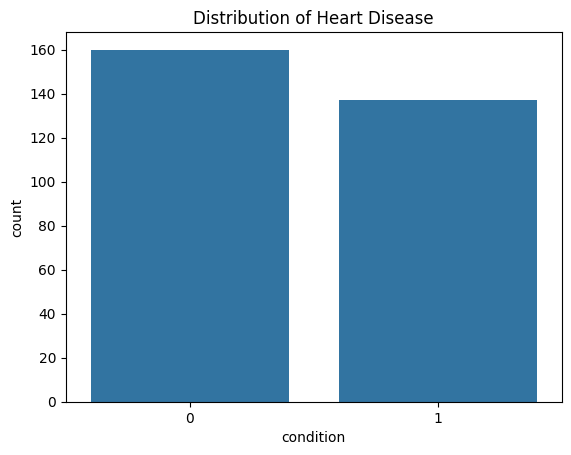

In [20]:
# Plot class distribution

sns.countplot(x="condition", data=df)

plt.title("Distribution of Heart Disease")

plt.show()

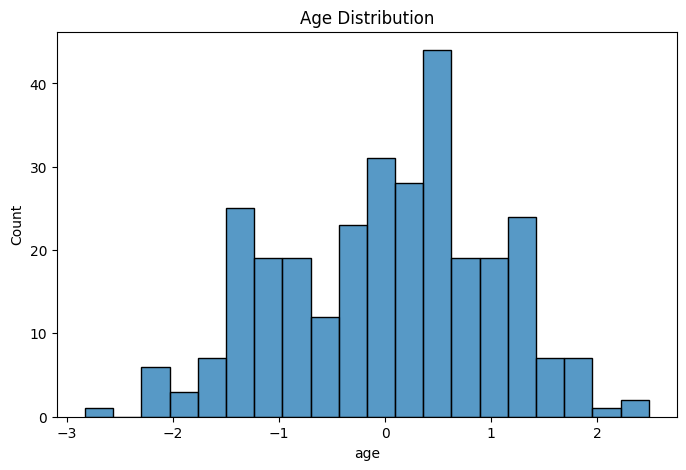

In [21]:
# Distribution of Age

plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=20)

plt.title("Age Distribution")

plt.show()

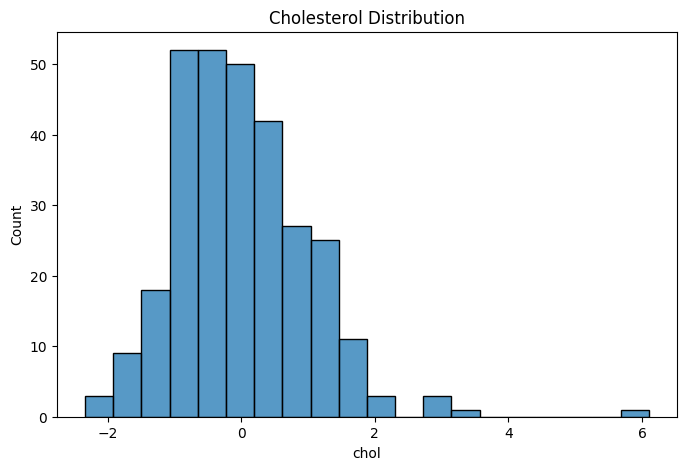

In [22]:
# Distribution of Cholesterol

plt.figure(figsize=(8,5))

sns.histplot(df["chol"], bins=20)

plt.title("Cholesterol Distribution")

plt.show()

In [23]:
correlation

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
age,1.000000,-0.092399,0.110471,0.290476,0.202644,0.132062,0.149917,-0.394563,0.096489,0.197123,0.159405,0.362210,0.120795,0.227075
sex,-0.092399,1.000000,0.008908,-0.066340,-0.198089,0.038850,0.033897,-0.060496,0.143581,0.106567,0.033345,0.091925,0.370556,0.278467
cp,0.110471,0.008908,1.000000,-0.036980,0.072088,-0.057663,0.063905,-0.339308,0.377525,0.203244,0.151079,0.235644,0.266275,0.408945
trestbps,0.290476,-0.066340,-0.036980,1.000000,0.131536,0.180860,0.149242,-0.049108,0.066691,0.191243,0.121172,0.097954,0.130612,0.153490
chol,0.202644,-0.198089,0.072088,0.131536,1.000000,0.012708,0.165046,-0.000075,0.059339,0.038596,-0.009215,0.115945,0.023441,0.080285
fbs,0.132062,0.038850,-0.057663,0.180860,0.012708,1.000000,0.068831,-0.007842,-0.000893,0.008311,0.047819,0.152086,0.051038,0.003167
restecg,0.149917,0.033897,0.063905,0.149242,0.165046,0.068831,1.000000,-0.072290,0.081874,0.113726,0.135141,0.129021,0.013612,0.166343
thalach,-0.394563,-0.060496,-0.339308,-0.049108,-0.000075,-0.007842,-0.072290,1.000000,-0.384368,-0.347640,-0.389307,-0.268727,-0.258386,-0.423817
exang,0.096489,0.143581,0.377525,0.066691,0.059339,-0.000893,0.081874,-0.384368,1.000000,0.289310,0.250572,0.148232,0.323268,0.421355
oldpeak,0.197123,0.106567,0.203244,0.191243,0.038596,0.008311,0.113726,-0.347640,0.289310,1.000000,0.579037,0.294452,0.336809,0.424052


In [24]:
target_corr

condition    1.000000
thal         0.520516
ca           0.463189
oldpeak      0.424052
exang        0.421355
cp           0.408945
slope        0.333049
sex          0.278467
age          0.227075
restecg      0.166343
trestbps     0.153490
chol         0.080285
fbs          0.003167
thalach     -0.423817
Name: condition, dtype: float64

## Analysis of Feature-Target Interaction Matrix

The correlation matrix shows the relationship between the clinical features and the target variable (**condition**).

From the analysis, the features with the strongest positive correlation with heart disease are:

| Feature | Correlation |
|----------|------------:|
| thal | 0.5205 |
| ca | 0.4632 |
| oldpeak | 0.4241 |
| exang | 0.4214 |
| cp | 0.4089 |
| slope | 0.3330 |

The feature **thalach (-0.4238)** has the strongest negative correlation with the target variable, indicating that patients with higher maximum heart rates are generally less likely to have heart disease in this dataset.

Other features such as **age (0.2271)**, **sex (0.2785)**, **restecg (0.1663)**, and **trestbps (0.1535)** have a weaker positive relationship with heart disease. The **fbs (0.0032)** feature shows almost no correlation with the target variable.

Based on this analysis, **thal**, **ca**, **oldpeak**, **exang**, and **cp** are the most important features for predicting heart disease and can be considered significant predictors during model development.

## Analysis of Correlation with Target Variable

The correlation analysis shows how strongly each clinical feature is related to the target variable (**condition**).

The feature **thal (0.5205)** has the highest positive correlation with the target variable, followed by **ca (0.4632)**, **oldpeak (0.4241)**, **exang (0.4214)**, and **cp (0.4089)**. These features have a stronger influence on predicting the presence of heart disease.

The feature **thalach (-0.4238)** has the strongest negative correlation with the target variable. This indicates that patients with a higher maximum heart rate are generally less likely to have heart disease in this dataset.

Features such as **age (0.2271)**, **sex (0.2785)**, **restecg (0.1663)**, **trestbps (0.1535)**, and **chol (0.0803)** show a weak positive correlation with the target variable, while **fbs (0.0032)** has almost no correlation.

Based on this analysis, **thal**, **ca**, **oldpeak**, **exang**, and **cp** are the most important features for predicting heart disease and can be considered useful predictors while building a machine learning model.

# Comparison Report

## Data Science Predictive Modeling vs Static Rule-Based Thresholds

| Data Science Predictive Modeling | Static Rule-Based Thresholds |
|---------------------------------|------------------------------|
| Learns patterns from historical data | Uses predefined rules |
| Considers multiple clinical features together | Uses one or a few fixed conditions |
| Improves as more data becomes available | Rules must be manually updated |
| Can achieve higher prediction accuracy | Less flexible and less accurate |
| Suitable for complex healthcare problems | Suitable for simple decision making |

### Summary

A rule-based system follows fixed conditions such as **"If cholesterol > 240, then high risk."** Although simple to implement, it cannot capture complex relationships between multiple clinical factors.

In contrast, data science predictive modeling learns from historical patient data and considers several features simultaneously. This approach provides more accurate predictions and helps clinicians identify high-risk patients at an earlier stage, leading to better healthcare decisions.

# Conclusion

The Heart Disease dataset was successfully loaded and preprocessed using Pandas. Categorical variables were converted into the appropriate data type, outliers were detected using the IQR method, and feature relationships were analyzed using a correlation heatmap.

The numerical features were normalized using StandardScaler, and a new feature called **Age-adjusted Max Heart Rate** was created through feature engineering.

The analysis showed that **thal**, **ca**, **oldpeak**, **exang**, and **cp** are among the most influential features for predicting heart disease. These findings can be used to build an effective machine learning model for early diagnosis and clinical decision support.